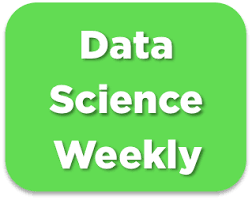

# Who subscribes to the newsletter — and what can be done about it?

*www.datascienceweekly.org* wants a model that predicts whether a visitor will subscribe, and they
want it for a reason: they would like to read the model's parameters, find a lever, and raise a
conversion rate that currently sits at **3.2%**.

This notebook builds that model. It reaches **f1 = 0.77** on unseen visitors, and the useful part
of the project is what happens when you ask the model for the lever:

> The score is almost entirely carried by **how many pages the visitor read** — a number that only
> exists *after* the visit and cannot be decided by anyone. Strip it out and the f1 falls from
> **0.77 to 0.21**.
>
> The one column marketing can act on before the visit is the **country**, and it holds the whole
> opportunity: **China is 24% of the traffic and 1% of the sign-ups.**

Everything below is the evidence for those two sentences, in the order the brief asks for it.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the file, establish what one row is, and fix the metric |
| 2 | What looks like cleaning here — and what each rule would cost |
| 3 | Where the conversions are: the page counter, the country, the visitor |
| 4 | Part 1 — baseline: a logistic regression on the five columns |
| 5 | Part 2 — improving the f1: the threshold, other model families, and when to stop |
| 6 | Part 3 — the submission file |
| 7 | Part 4 — reading the coefficients |
| 8 | What the newsletter team should do |

Every claim below is the output of the cell above it.

## 1. The file and the metric

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: the train/test split, the cross-validation folds and the
# stability study in section 5 all read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a sign or a contrast.
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()

In [2]:
df = pd.read_csv('conversion_data_train.csv')

print(f'{df.shape[0]} rows x {df.shape[1]} columns')
df.head()

284580 rows x 6 columns


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


### What is one row?

**One row is one visit to the website**, described by five columns and labelled by what happened at
the end of it:

| Column | What it is | Known when? |
|---|---|---|
| `country` | where the visitor connects from — 4 values | before the visit |
| `age` | the visitor's age | before the visit |
| `new_user` | 1 if this is a first visit, 0 if the visitor already has an account | before the visit |
| `source` | how they arrived — `Seo`, `Ads`, `Direct` | at the start of the visit |
| `total_pages_visited` | how many pages they read | **only at the end** |
| `converted` | 1 if they subscribed to the newsletter | the outcome |

In [3]:
print(df.dtypes.to_string())
print(f'\nmissing values : {df.isna().sum().sum()}')
print(f'\nconversions    : {df["converted"].sum()} of {len(df)}  ({df["converted"].mean():.2%})')
print(df.describe().round(2).to_string())

country                  str
age                    int64
new_user               int64
source                   str
total_pages_visited    int64
converted              int64

missing values : 0

conversions    : 9180 of 284580  (3.23%)
             age   new_user  total_pages_visited  converted
count  284580.00  284580.00            284580.00  284580.00
mean       30.56       0.69                 4.87       0.03
std         8.27       0.46                 3.34       0.18
min        17.00       0.00                 1.00       0.00
25%        24.00       0.00                 2.00       0.00
50%        30.00       1.00                 4.00       0.00
75%        36.00       1.00                 7.00       0.00
max       123.00       1.00                29.00       1.00


### The metric, and why it is not accuracy

**3.2% of the visits convert.** On a target that rare, accuracy is meaningless: a model that
predicts *"nobody ever subscribes"* is right 96.8% of the time and useless. The challenge is scored
on the **f1-score of the positive class** — the harmonic mean of precision (of the visitors we
flag, how many really subscribe) and recall (of the visitors who subscribe, how many we flag) —
which that model scores 0 on.

Every score in this notebook is that f1-score, so it is directly comparable to the leaderboard.

In [4]:
never = np.zeros(len(df), dtype=int)
print(f'the "nobody subscribes" model: accuracy {(never == df["converted"]).mean():.1%}, '
      f'f1 {f1_score(df["converted"], never):.3f}')

the "nobody subscribes" model: accuracy 96.8%, f1 0.000


## 2. What looks like cleaning here — and what it would cost

The usual preprocessing checklist finds almost nothing to do on this file: **no missing value, no
mistyped column, no impossible category.** Two things do look like they need a rule, and both rules
would be wrong. They are worth a section because each one is a plausible reflex and each one is
expensive.

### 2.1 The 268 769 "duplicate" rows are not duplicates

In [5]:
FEATURES = ['country', 'age', 'new_user', 'source', 'total_pages_visited']

print(f'exactly duplicated rows            : {df.duplicated().sum()} of {len(df)}')
print(f'distinct feature combinations      : {df.groupby(FEATURES, observed=True).ngroups}')
print(f'the grid they live in              : 4 countries x {df["age"].nunique()} ages x 2 x 3 '
      f'x {df["total_pages_visited"].nunique()} page counts = '
      f'{4 * df["age"].nunique() * 2 * 3 * df["total_pages_visited"].nunique()} cells')

profiles = df.groupby(FEATURES, observed=True)['converted'].agg(['size', 'sum'])
mixed = profiles[(profiles['sum'] > 0) & (profiles['sum'] < profiles['size'])]
print(f'\nprofiles seen with BOTH outcomes   : {len(mixed)}, covering {mixed["size"].sum()} rows')

deduped = df.drop_duplicates()
print(f'\ndrop_duplicates() would leave      : {len(deduped)} rows '
      f'({1 - len(deduped) / len(df):.1%} of the file deleted)')
print(f'and would move the conversion rate : {df["converted"].mean():.2%} -> '
      f'{deduped["converted"].mean():.2%}')

exactly duplicated rows            : 268769 of 284580
distinct feature combinations      : 13942
the grid they live in              : 4 countries x 60 ages x 2 x 3 x 29 page counts = 41760 cells

profiles seen with BOTH outcomes   : 1869, covering 38977 rows

drop_duplicates() would leave      : 15811 rows (94.4% of the file deleted)
and would move the conversion rate : 3.23% -> 25.70%


Five columns, four of them with a handful of values, describe **13 942 distinct visitor profiles** out of
284 580 visits. Two visits with the same country, age, status, source and page count are not the
same visit recorded twice — they are two different people who look alike, and **1 869 of those
profiles appear with both outcomes**: same description, one subscribed and one did not.

So `drop_duplicates()` here is not cleaning. It deletes 94% of the file, and because a profile that
converted survives exactly as well as one that did not, it turns a **3.2%** conversion rate into
**25.7%** — a different problem, with a different answer. Section 5.3 prices it: the same model
trained on the deduplicated file loses **8.6 points of f1**.

### 2.2 Two ages are impossible, and removing them changes nothing

In [6]:
print(df[df['age'] >= 70].sort_values('age').to_string(index=False))
print(f'\nage range in the labelled file   : {df["age"].min()} to {df["age"].max()}')
print(f'age range in the file to predict : '
      f'{pd.read_csv("conversion_data_test.csv")["age"].min()} to '
      f'{pd.read_csv("conversion_data_test.csv")["age"].max()}')

country  age  new_user source  total_pages_visited  converted
     US   70         1    Ads                    9          0
     UK   70         0    Ads                    5          0
     US   72         1 Direct                    4          0
     US   73         1    Seo                    5          0
     US   77         0 Direct                    4          0
     US   79         1 Direct                    1          0
     UK  111         0    Ads                   10          1
Germany  123         0    Seo                   15          1

age range in the labelled file   : 17 to 123
age range in the file to predict : 17 to 69


A visitor of **123** and one of **111**. They are data-entry errors, and the six other rows above
70 are merely rare.

The reflex is a ±3σ filter. It is not applied here, for two reasons that are both measurements
rather than opinions: these 8 rows are **0.003% of the file**, and the file we have to predict
contains **nobody above 69**, so nothing in the submission depends on how the tail is treated.
Section 5.3 confirms it — dropping them moves the test f1 by **+0.0003**. The rows stay, and the
notebook says why rather than silently trimming a distribution.

## 3. Where the conversions are

In [7]:
def rate_table(col):
    """Traffic share and conversion rate for one categorical column."""
    g = df.groupby(col, observed=True)['converted'].agg(visits='size', converted='sum', rate='mean')
    g['share of traffic'] = g['visits'] / len(df)
    return g.sort_values('rate', ascending=False)


for col in ['country', 'new_user', 'source']:
    print(rate_table(col).round(4).to_string(), '\n')

         visits  converted    rate  share of traffic
country                                             
Germany   11693        730  0.0624            0.0411
UK        43641       2291  0.0525            0.1534
US       160124       6070  0.0379            0.5627
China     69122         89  0.0013            0.2429 

          visits  converted    rate  share of traffic
new_user                                             
0          89514       6439  0.0719            0.3145
1         195066       2741  0.0141            0.6855 

        visits  converted    rate  share of traffic
source                                             
Ads      80027       2785  0.0348            0.2812
Seo     139477       4585  0.0329            0.4901
Direct   65076       1810  0.0278            0.2287 



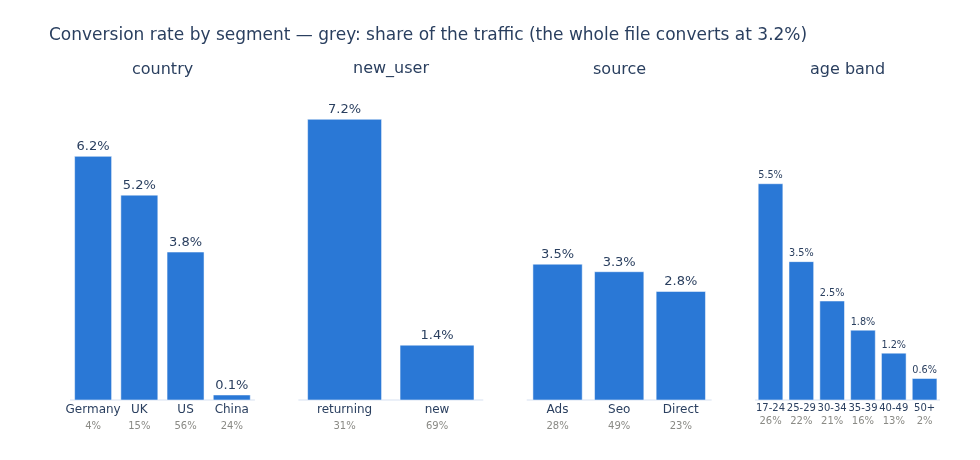

In [8]:
AGE_BANDS = [16, 24, 29, 34, 39, 49, 130]
age_band = pd.cut(df['age'], AGE_BANDS, labels=['17-24', '25-29', '30-34', '35-39', '40-49', '50+'])

panels = [('country', rate_table('country').index.tolist()),
          ('new_user', [0, 1]),
          ('source', rate_table('source').index.tolist()),
          ('age band', list(age_band.cat.categories))]

fig = make_subplots(rows=1, cols=4, subplot_titles=[p[0] for p in panels],
                    horizontal_spacing=0.05)
for i, (col, order) in enumerate(panels, start=1):
    key = age_band if col == 'age band' else df[col]
    g = df.groupby(key, observed=True)['converted'].agg(['size', 'mean']).reindex(order)
    names = ['returning' if v == 0 else 'new' for v in order] if col == 'new_user' else \
            [str(v) for v in order]
    # The share of traffic goes under the tick label rather than on top of the bar: on the
    # narrow panels the two-line bar label overlapped its neighbour.
    labels = [f'{name}<br><span style="font-size:10px;color:#8a8a85">{n / len(df):.0%}</span>'
              for name, n in zip(names, g['size'])]
    fig.add_trace(go.Bar(
        x=labels, y=g['mean'], marker_color=BLUE,
        text=[f'{v:.1%}' for v in g['mean']],
        textposition='outside', cliponaxis=False, showlegend=False, textfont=dict(size=13),
    ), row=1, col=i)
fig.update_yaxes(range=[0, 0.082], showticklabels=False, showgrid=False)
fig.update_xaxes(tickangle=0, tickfont=dict(size=12))
fig.update_xaxes(tickfont=dict(size=10), row=1, col=4)   # six bands in one panel
fig.update_layout(title='Conversion rate by segment — grey: share of the traffic '
                        '(the whole file converts at 3.2%)')
show(fig, '1_conversion_by_segment', height=460)

Three of the four panels carry a real difference, and one is flat:

- **Country is the widest split in the file.** Germany converts at **6.2%** and China at **0.13%**
  — a factor of **48** — and China is not a niche: it is **24% of all visits**.
- **Returning visitors convert 5 times better than new ones** (7.2% against 1.4%). They are also
  the minority of the traffic (31%).
- **Age falls monotonically**, 5.5% for the 17-24s down to 0.55% above 50.
- **Source does not matter.** `Ads` 3.5%, `Seo` 3.3%, `Direct` 2.8% — the three channels the
  marketing budget is actually split between are within half a point of each other. Section 5.3
  confirms the model can be given the column or not, for 0.002 of f1.

### 3.1 The page counter is a different kind of column

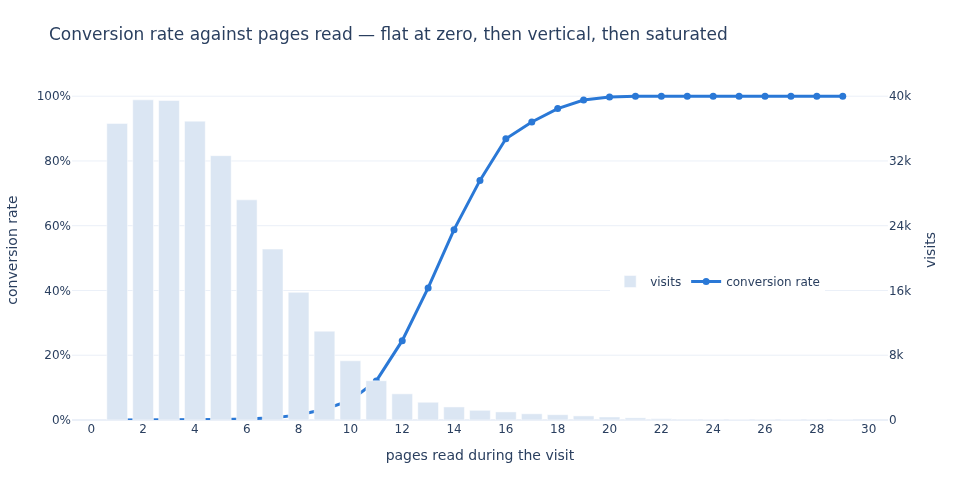

point-biserial correlation with the target: 0.529
median visit: 4 pages   (65% of visits read 5 pages or fewer)


In [9]:
by_pages = df.groupby('total_pages_visited')['converted'].agg(visits='size', rate='mean')

fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Bar(x=by_pages.index, y=by_pages['visits'], marker_color='#dbe6f3',
                     name='visits', hovertemplate='%{y} visits'), secondary_y=True)
fig.add_trace(go.Scatter(x=by_pages.index, y=by_pages['rate'], mode='lines+markers',
                         line=dict(color=BLUE, width=3), marker=dict(size=7),
                         name='conversion rate'), secondary_y=False)
fig.update_layout(
    title='Conversion rate against pages read — flat at zero, then vertical, then saturated',
    xaxis=dict(title='pages read during the visit', dtick=2),
    legend=dict(orientation='h', y=0.45, x=0.62),   # under the curve, where the panel is empty
)
fig.update_yaxes(title='conversion rate', tickformat='.0%', range=[0, 1.05], secondary_y=False)
fig.update_yaxes(title='visits', showgrid=False, range=[0, 42_000], secondary_y=True)
show(fig, '2_pages_curve', height=480)

print(f'point-biserial correlation with the target: '
      f'{df["total_pages_visited"].corr(df["converted"]):.3f}')
print(f'median visit: {df["total_pages_visited"].median():.0f} pages   '
      f'({(df["total_pages_visited"] <= 5).mean():.0%} of visits read 5 pages or fewer)')

This is not a segment, it is a **switch**. Below 5 pages the conversion rate is under 0.2%; at 15
pages it is 74%; from 21 pages on, **every single visitor in the file subscribed**. The correlation
with the target is **0.53**, five times anything else in the file.

Which is also the problem with it. Nobody at the newsletter decides how many pages a visitor reads;
it is the visitor's interest, measured after the fact. A model built on it will be accurate and
will tell marketing nothing they can act on — unless they use it *during* the session, which is a
real use and section 8 comes back to it.

### 3.2 China does not read less — it stops at the same place

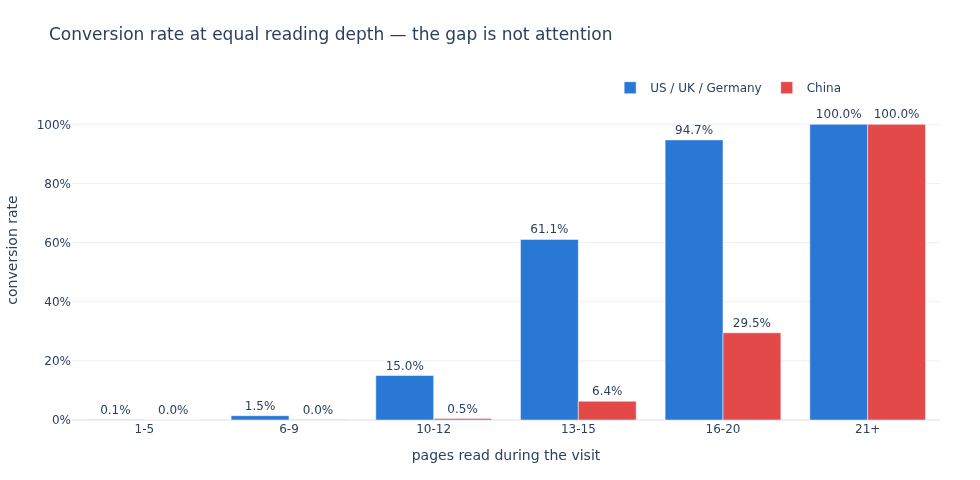

mean pages read — China 4.55, elsewhere 4.98


In [10]:
depth = pd.cut(df['total_pages_visited'], [0, 5, 9, 12, 15, 20, 30],
               labels=['1-5', '6-9', '10-12', '13-15', '16-20', '21+'])
china = np.where(df['country'] == 'China', 'China', 'US / UK / Germany')
gap = df.groupby([china, depth], observed=True)['converted'].agg(['size', 'mean']).unstack(0)

fig = go.Figure()
for name, color in [('US / UK / Germany', BLUE), ('China', RED)]:
    fig.add_trace(go.Bar(x=gap['mean'].index.astype(str), y=gap['mean'][name], name=name,
                         marker_color=color, text=[f'{v:.1%}' for v in gap['mean'][name]],
                         textposition='outside', cliponaxis=False))
fig.update_layout(
    title='Conversion rate at equal reading depth — the gap is not attention',
    # type='category': left to itself, plotly reads a label like '13-15' as a date.
    xaxis=dict(title='pages read during the visit', type='category'),
    yaxis=dict(title='conversion rate', tickformat='.0%', range=[0, 1.15]),
    legend=dict(orientation='h', y=1.02, x=0.62), barmode='group',
)
show(fig, '3_china_gap', height=480)

print(f'mean pages read — China {df.loc[df["country"] == "China", "total_pages_visited"].mean():.2f}, '
      f'elsewhere {df.loc[df["country"] != "China", "total_pages_visited"].mean():.2f}')

**Chinese visitors browse like everyone else** — 4.55 pages on average against 4.98 — and then do
not subscribe. At 13 to 15 pages read, a visitor converts at **61%** from the US, the UK or
Germany, and at **6%** from China. At 6 to 12 pages the gap is a factor of **30**; it narrows to 3
at 16-20 pages and closes only in the last bar, where China has three visits in the whole file.

A gap that survives at equal reading depth is not a gap in interest. Something at the **last step**
— the sign-up form itself — behaves differently for these visitors, and section 8 says what to do
about it. This single fact is the largest number in the project: China is 24% of the traffic and
**1% of the sign-ups**.

## 4. Part 1 — the baseline: a logistic regression

### 4.1 The pipeline

Two families of columns, treated differently, both fitted **on the training set only** so that
nothing about the held-out visitors leaks into the model:

- **Numerical** — `age` and `total_pages_visited`, standardised. They share no unit (a count of
  pages against a count of years) and their coefficients are only comparable once they do.
- **Categorical** — `country`, `source` and `new_user`, one-hot encoded. `new_user` is already 0/1
  and would survive as it is, but passing it through the same encoder keeps one rule for one kind
  of column instead of an exception to explain.

No imputer: section 2 established that nothing is missing, and a step that never fires is a step
that hides what the pipeline really does. The split is **stratified** — at 3.2% positives, an
unstratified split would let the test set's conversion rate drift by a tenth of its own value.

In [11]:
NUMERIC = ['age', 'total_pages_visited']
CATEGORICAL = ['country', 'source', 'new_user']

X, y = df[NUMERIC + CATEGORICAL], df['converted']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    # drop='first': with an intercept in the model, keeping every level of a column would make
    # them perfectly collinear with it. One level becomes the reference and the others are read
    # against it -- China for the country, Ads for the source, "returning visitor" for new_user.
    ('cat', OneHotEncoder(drop='first'), CATEGORICAL),
])

baseline = Pipeline([('pre', preprocessor),
                     ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)

print(f'train {len(X_train)} visits ({y_train.mean():.2%} converted)   '
      f'test {len(X_test)} visits ({y_test.mean():.2%} converted)')
print(f'features after encoding: {len(baseline.named_steps["pre"].get_feature_names_out())}')

train 227664 visits (3.23% converted)   test 56916 visits (3.23% converted)
features after encoding: 8


### 4.2 Score

In [12]:
def report(y_true, proba, threshold, label):
    """One row of the comparison table, plus its confusion matrix."""
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f'{label:22s} f1 {f1_score(y_true, pred):.4f}   '
          f'precision {tp / (tp + fp):.3f}   recall {tp / (tp + fn):.3f}   '
          f'| TP {tp:5d}  FP {fp:4d}  FN {fn:4d}  TN {tn:6d}')


proba_train = baseline.predict_proba(X_train)[:, 1]
proba_test = baseline.predict_proba(X_test)[:, 1]
report(y_train, proba_train, 0.5, 'train')
report(y_test, proba_test, 0.5, 'test')

train                  f1 0.7618   precision 0.855   recall 0.687   | TP  5045  FP  856  FN 2299  TN 219464
test                   f1 0.7678   precision 0.867   recall 0.689   | TP  1265  FP  194  FN  571  TN  54886


**f1 = 0.768 on the test set, 0.762 on the training set.** The two are within half a point of each
other, which settles the overfitting question before it is asked: eight features on 227 664 rows
leaves nothing to memorise. Regularisation has nothing to fight here, which is why section 5.2
tunes it once, finds nothing, and moves on.

The confusion matrix is where the score becomes a business statement. Of the 1 836 visitors who
subscribed in the test set, the model finds **1 265** and misses **571**; of the 1 459 it flags, it
is right **1 265** times. Precision **0.87**, recall **0.69** — the model is cautious, and the next
section is about the fact that nobody asked it to be.

## 5. Part 2 — improving the f1

### 5.1 The threshold is the first lever, and the cheapest

`predict()` calls a visitor a subscriber above a probability of **0.5**. That 0.5 is not a property
of the problem — it is the decision that minimises the *error count*, on a file where 96.8% of the
answers are "no". The f1-score does not count errors, it balances precision against recall, and its
best threshold is somewhere else.

The threshold is chosen **by cross-validation on the training set only**: reading it off the test
set would be fitting a parameter to the data used to report the score.

In [13]:
def best_threshold(y_true, proba):
    """The threshold that maximises the f1-score, and the f1 it reaches."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
    best = np.nanargmax(f1[:-1])
    return thresholds[best], f1[best]


cv_proba = cross_val_predict(baseline, X_train, y_train, method='predict_proba',
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))[:, 1]
THRESHOLD, cv_f1 = best_threshold(y_train, cv_proba)

print(f'threshold chosen by 5-fold cross-validation on the training set: {THRESHOLD:.3f} '
      f'(cross-validated f1 {cv_f1:.4f})\n')
report(y_test, proba_test, 0.5, 'test @ 0.5')
report(y_test, proba_test, THRESHOLD, f'test @ {THRESHOLD:.3f}')
print(f'\nfor reference, the best threshold readable on the test set itself would give '
      f'{best_threshold(y_test, proba_test)[1]:.4f}')

threshold chosen by 5-fold cross-validation on the training set: 0.399 (cross-validated f1 0.7705)

test @ 0.5             f1 0.7678   precision 0.867   recall 0.689   | TP  1265  FP  194  FN  571  TN  54886
test @ 0.399           f1 0.7743   precision 0.814   recall 0.738   | TP  1355  FP  309  FN  481  TN  54771

for reference, the best threshold readable on the test set itself would give 0.7773


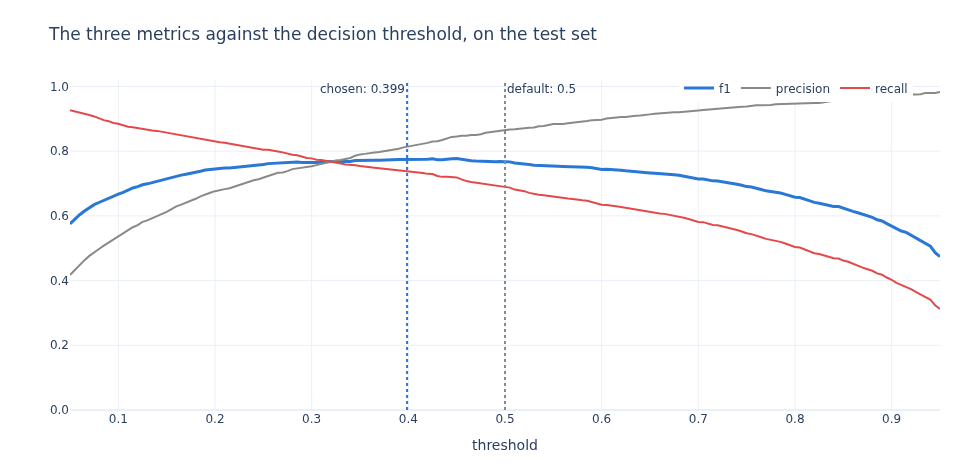

In [14]:
grid = np.linspace(0.05, 0.95, 181)
curves = {'f1': [], 'precision': [], 'recall': []}
for t in grid:
    pred = (proba_test >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    curves['f1'].append(f1_score(y_test, pred))
    curves['precision'].append(tp / max(pred.sum(), 1))
    curves['recall'].append(tp / y_test.sum())

fig = go.Figure()
for key, color, width in [('f1', BLUE, 3), ('precision', GREY, 2), ('recall', RED, 2)]:
    fig.add_trace(go.Scatter(x=grid, y=curves[key], mode='lines', name=key,
                             line=dict(color=color, width=width)))
fig.add_vline(x=THRESHOLD, line_dash='dot', line_color=BLUE,
              annotation_text=f'chosen: {THRESHOLD:.3f}', annotation_position='top left')
fig.add_vline(x=0.5, line_dash='dot', line_color=GREY,
              annotation_text='default: 0.5', annotation_position='top right')
fig.update_layout(
    title='The three metrics against the decision threshold, on the test set',
    xaxis=dict(title='threshold'), yaxis=dict(title=None, tickformat='.1f', range=[0, 1.02]),
    legend=dict(orientation='h', y=1.02, x=0.7),
)
show(fig, '4_threshold', height=470)

**0.399, and it is worth +0.006 of f1** — from 0.7678 to 0.7743. The model now flags 1 664
visitors instead of 1 459: it trades 115 false positives for 90 additional subscribers found, which
the f1-score counts as a gain and the error count would not.

Two things make this a real improvement rather than a lucky split. The best threshold that could be
read *off the test set itself* is worth 0.7773 — so the cross-validated choice captures almost all
of what is there. And the value is stable: the next cell re-runs the entire procedure on 10
different splits.

In [15]:
# The whole procedure, 10 times over: split, fit, tune the threshold on the training half only,
# score on the held-out half. This is what a leaderboard submission is actually worth.
runs = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    pipe = Pipeline([('pre', preprocessor),
                     ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    pipe.fit(Xtr, ytr)
    t, _ = best_threshold(ytr, pipe.predict_proba(Xtr)[:, 1])
    runs.append({'seed': seed, 'threshold': t,
                 'f1': f1_score(yte, pipe.predict_proba(Xte)[:, 1] >= t)})

runs = pd.DataFrame(runs)
print(f'over 10 splits: threshold {runs["threshold"].mean():.3f} +/- {runs["threshold"].std():.3f}'
      f'   f1 {runs["f1"].mean():.4f} +/- {runs["f1"].std():.4f}'
      f'   (min {runs["f1"].min():.4f}, max {runs["f1"].max():.4f})')

over 10 splits: threshold 0.399 +/- 0.005   f1 0.7681 +/- 0.0057   (min 0.7567, max 0.7758)


The threshold lands on **0.40 every time**. The f1 does not: it moves by ±0.006 from one split to
another, which is the number to keep in mind for the rest of this section — **a model that beats
another by less than a hundredth of a point has not beaten it.**

### 5.2 Other model families

A logistic regression draws one straight boundary through the encoded features. Section 3.1 showed
a curve that is anything but straight, so the obvious next move is a model that can bend. Both
ensembles below are given the same pipeline and the same threshold treatment, so the comparison is
about the model and nothing else.

In [16]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'RandomForest (depth 8)': RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1,
                                                     random_state=RANDOM_STATE),
    'RandomForest (unpruned)': RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                      random_state=RANDOM_STATE),
}

rows = []
for name, model in candidates.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)]).fit(X_train, y_train)
    p_tr, p_te = pipe.predict_proba(X_train)[:, 1], pipe.predict_proba(X_test)[:, 1]
    t, _ = best_threshold(y_train, p_tr)
    rows.append({'model': name, 'threshold': round(t, 3),
                 'f1 train': f1_score(y_train, p_tr >= t), 'f1 test': f1_score(y_test, p_te >= t)})

# The penalty strength of the logistic regression, tuned on the f1 rather than left at C=1.
search = GridSearchCV(baseline, {'model__C': np.logspace(-3, 3, 13)}, scoring='f1', cv=5,
                      n_jobs=-1).fit(X_train, y_train)
p_tr = search.best_estimator_.predict_proba(X_train)[:, 1]
p_te = search.best_estimator_.predict_proba(X_test)[:, 1]
t, _ = best_threshold(y_train, p_tr)
rows.append({'model': f'LogisticRegression (C={search.best_params_["model__C"]:.2f})',
             'threshold': round(t, 3), 'f1 train': f1_score(y_train, p_tr >= t),
             'f1 test': f1_score(y_test, p_te >= t)})

print(pd.DataFrame(rows).round(4).to_string(index=False))

                      model  threshold  f1 train  f1 test
         LogisticRegression      0.398    0.7702   0.7745
       HistGradientBoosting      0.408    0.7733   0.7705
     RandomForest (depth 8)      0.402    0.7737   0.7669
    RandomForest (unpruned)      0.412    0.8113   0.7424
LogisticRegression (C=0.32)      0.392    0.7699   0.7736


**Nothing beats the straight line.** The gradient boosting lands 0.004 below it and the pruned
forest 0.008 — both inside the ±0.006 that section 5.1 measured between two random splits. The
unpruned forest is the only clear result in the table, and it is a negative one: 0.81 on train
against 0.74 on test is a model memorising 227 664 rows of a 13 942-cell grid.

Tuning the regularisation strength does not help either — cross-validation picks C = 0.32 out of
seven orders of magnitude and gains nothing, for the same reason as before: with eight features and
a quarter of a million rows, there is no variance to trade away.

The curve of section 3.1 *is* an S-curve, and an S-curve is exactly what a logistic regression
fits. The boundary was never the hard part of this problem.

### 5.3 So where does the score come from, and how much is left?

Two questions decide whether to keep engineering. The first: which columns is the model actually
using — the ones marketing can act on, or the one it cannot? The second: how far is 0.774 from the
best score anyone could get out of these five columns?

In [17]:
def group_f1(numeric, categorical):
    """Rebuild the whole pipeline on one group of columns and score it the same way."""
    steps = ([('num', StandardScaler(), numeric)] if numeric else []) + \
            ([('cat', OneHotEncoder(drop='first'), categorical)] if categorical else [])
    pipe = Pipeline([('pre', ColumnTransformer(steps)),
                     ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    cols = numeric + categorical
    pipe.fit(X_train[cols], y_train)
    t, _ = best_threshold(y_train, pipe.predict_proba(X_train[cols])[:, 1])
    return f1_score(y_test, pipe.predict_proba(X_test[cols])[:, 1] >= t)


groups = {
    'every column (the model above)':   (NUMERIC, CATEGORICAL),
    'total_pages_visited alone':        (['total_pages_visited'], []),
    'pages + country':                  (['total_pages_visited'], ['country']),
    'pages + country + new_user':       (['total_pages_visited'], ['country', 'new_user']),
    'every column EXCEPT source':       (NUMERIC, ['country', 'new_user']),
    'every column EXCEPT pages':        (['age'], CATEGORICAL),
    'new_user alone':                   ([], ['new_user']),
    'age alone':                        (['age'], []),
    'country alone':                    ([], ['country']),
    'source alone':                     ([], ['source']),
}
for label, (num, cat) in groups.items():
    print(f'{label:34s} f1 = {group_f1(num, cat):.4f}')

every column (the model above)     f1 = 0.7745
total_pages_visited alone          f1 = 0.7141
pages + country                    f1 = 0.7287
pages + country + new_user         f1 = 0.7658
every column EXCEPT source         f1 = 0.7723
every column EXCEPT pages          f1 = 0.2082
new_user alone                     f1 = 0.1310
age alone                          f1 = 0.1031
country alone                      f1 = 0.0894
source alone                       f1 = 0.0645


**This is the finding of the project.**

`total_pages_visited` on its own scores **0.714** — 92% of the full model, from one column. Every
other column *together*, with the page counter removed, scores **0.208**. The country, the age, the
status and the channel are not weak predictors of who subscribes: at the moment a visitor lands on
the site, **they barely predict at all.**

And the ordering inside the table is the marketing brief in miniature. Adding `country` to the page
counter is worth +0.015, adding `new_user` another +0.037, `age` +0.007 — and `source`, the column
that maps most directly onto a budget line, is worth **0.002**.

In [18]:
# How much is left on the table? An oracle that knows the conversion rate of every one of the
# 13 942 profiles -- measured on this very file, so it is an optimistic ceiling, not a score --
# and is allowed the best threshold for it.
rate_by_profile = df.groupby(FEATURES, observed=True)['converted'].transform('mean')
ceiling_threshold, ceiling = best_threshold(y, rate_by_profile)
unavoidable = np.minimum(profiles['sum'], profiles['size'] - profiles['sum']).sum()

print(f'optimistic ceiling on these five columns : f1 {ceiling:.4f} (at threshold {ceiling_threshold:.3f})')
print(f'our model                                : f1 {f1_score(y_test, proba_test >= THRESHOLD):.4f}')
print(f'\nvisits an oracle still has to get wrong  : {unavoidable} '
      f'(the minority outcome of a profile seen with both)')

# The two rules of section 2, priced.
dedup_train = df.loc[X_train.index].drop_duplicates()
pipe = Pipeline([('pre', preprocessor),
                 ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
pipe.fit(dedup_train[NUMERIC + CATEGORICAL], dedup_train['converted'])
t, _ = best_threshold(dedup_train['converted'],
                      pipe.predict_proba(dedup_train[NUMERIC + CATEGORICAL])[:, 1])
print(f'\n2.1  trained on the deduplicated file     : f1 {f1_score(y_test, pipe.predict_proba(X_test)[:, 1] >= t):.4f}'
      f'  ({len(dedup_train)} rows instead of {len(X_train)})')

young = X_train['age'] < 70
pipe = Pipeline([('pre', preprocessor),
                 ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
pipe.fit(X_train[young], y_train[young])
t, _ = best_threshold(y_train[young], pipe.predict_proba(X_train[young])[:, 1])
print(f'2.2  trained without the 8 ages over 70   : f1 {f1_score(y_test, pipe.predict_proba(X_test)[:, 1] >= t):.4f}')

optimistic ceiling on these five columns : f1 0.8055 (at threshold 0.417)
our model                                : f1 0.7743

visits an oracle still has to get wrong  : 3358 (the minority outcome of a profile seen with both)

2.1  trained on the deduplicated file     : f1 0.6885  (14906 rows instead of 227664)
2.2  trained without the 8 ages over 70   : f1 0.7748


**0.774 against a ceiling of 0.806** — and that ceiling is generous, since it was measured on the
same file it describes. **3 358 visits** in this dataset are described by a profile that appears
with both outcomes: two people, same country, same age, same status, same source, same number of
pages, and only one of them subscribed. No model reading these five columns can separate them.

So the remaining three points are not waiting for a better algorithm — they are the part of the
decision that lives outside the file. **Stopping here is a measurement, not a shrug.**

The two rules of section 2 come out as announced: deduplicating costs **8.6 points**, and the age
outliers are worth **0.0003**.

## 6. Part 3 — the submission

The model is refit on **all 284 580 labelled visits** — the 20% held out for testing included,
since the score has now been measured and the extra rows can only help — and applied to the
unlabelled file with the threshold chosen in section 5.1.

In [19]:
final = Pipeline([('pre', preprocessor),
                  ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
final.fit(X, y)

to_predict = pd.read_csv('conversion_data_test.csv')
proba = final.predict_proba(to_predict[NUMERIC + CATEGORICAL])[:, 1]
predictions = pd.DataFrame({'converted': (proba >= THRESHOLD).astype(int)})

FILENAME = 'conversion_data_test_predictions_XAVIER-PAEZ-logreg.csv'
predictions.to_csv(FILENAME, index=False)

print(f'{FILENAME}: {len(predictions)} rows, one column named '
      f'{list(predictions.columns)}, no index')
print(f'predicted subscribers : {predictions["converted"].sum()} '
      f'({predictions["converted"].mean():.2%} of the file)')
print(f'observed in training  : {y.mean():.2%}')
print(f'\nexpected leaderboard f1: {runs["f1"].mean():.3f} +/- {runs["f1"].std():.3f} '
      f'(section 5.1, over 10 splits)')

conversion_data_test_predictions_XAVIER-PAEZ-logreg.csv: 31620 rows, one column named ['converted'], no index
predicted subscribers : 920 (2.91% of the file)
observed in training  : 3.23%

expected leaderboard f1: 0.768 +/- 0.006 (section 5.1, over 10 splits)


**One column, no index, 31 620 rows** — the format the challenge asks for. The model calls 2.9% of
the unlabelled visits subscribers against a 3.2% base rate, which is the arithmetic of a precision
of 0.81 at a recall of 0.74: it deliberately does not try to name every subscriber.

The number to expect on the leaderboard is **0.768 ± 0.006**, not the 0.774 of section 5.1 — that
one is a single split, and the ten splits above are what the procedure is really worth.

## 7. Part 4 — reading the coefficients

A logistic regression's coefficients are in log-odds, which nobody thinks in. Exponentiated they
become **odds ratios**: how many times the odds of subscribing are multiplied. The two numerical
columns were standardised, so their ratio is *"per one standard deviation"* — 8.3 years of age,
3.3 pages read. The categorical ones are read against a reference: **China**, **Ads**, **returning
visitor**.

                              coefficient  odds ratio
age  (+8.3 years)                  -0.598        0.55
pages read  (+3.3 pages)            2.524       12.48
country: Germany  (vs China)        3.609       36.94
country: UK  (vs China)             3.406       30.14
country: US  (vs China)             3.061       21.34
source: Direct  (vs Ads)           -0.217        0.80
source: Seo  (vs Ads)              -0.027        0.97
new visitor  (vs returning)        -1.713        0.18

intercept: -8.703


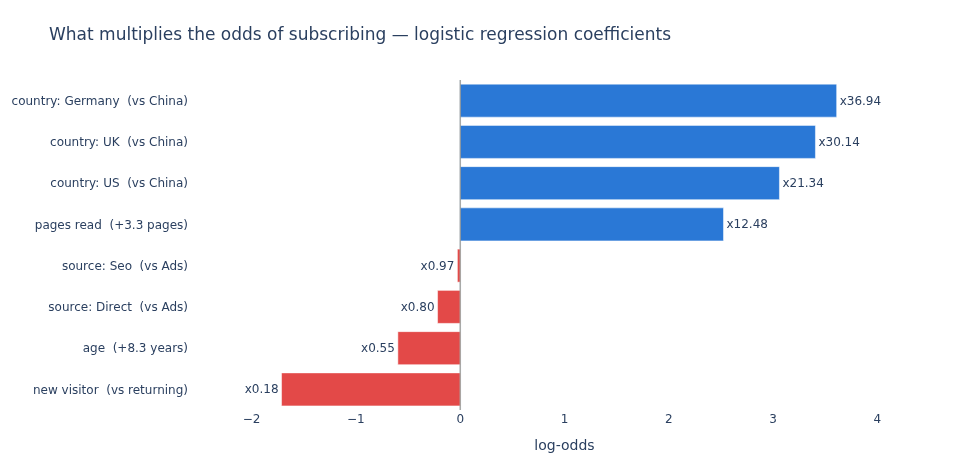

In [20]:
names = final.named_steps['pre'].get_feature_names_out()
coefs = pd.Series(final.named_steps['model'].coef_[0], index=names)
labels = {
    'num__age': 'age  (+8.3 years)',
    'num__total_pages_visited': 'pages read  (+3.3 pages)',
    'cat__country_Germany': 'country: Germany  (vs China)',
    'cat__country_UK': 'country: UK  (vs China)',
    'cat__country_US': 'country: US  (vs China)',
    'cat__source_Direct': 'source: Direct  (vs Ads)',
    'cat__source_Seo': 'source: Seo  (vs Ads)',
    'cat__new_user_1': 'new visitor  (vs returning)',
}
table = pd.DataFrame({'coefficient': coefs.round(3),
                      'odds ratio': np.exp(coefs).round(2)}).rename(index=labels)
print(table.to_string())
print(f'\nintercept: {final.named_steps["model"].intercept_[0]:.3f}')

ordered = coefs.rename(labels).sort_values()
fig = go.Figure(go.Bar(
    x=ordered.values, y=ordered.index, orientation='h',
    marker_color=[RED if v < 0 else BLUE for v in ordered.values],
    text=[f'x{np.exp(v):.2f}' for v in ordered.values],
    textposition='outside', cliponaxis=False,
))
fig.add_vline(x=0, line_width=1, line_color=GREY)
fig.update_layout(
    title='What multiplies the odds of subscribing — logistic regression coefficients',
    xaxis=dict(title='log-odds', showgrid=False, range=[-2.6, 4.6]),
    yaxis=dict(title=None),
)
show(fig, '5_coefficients', height=470)

Read in order of size:

- **Being outside China multiplies the odds by 21 to 37.** These are the largest coefficients in
  the model, and they are the ones section 3.2 already isolated: at equal reading depth, the same
  visitor converts an order of magnitude better from Germany than from China. Germany (×37), the UK
  (×30) and the US (×21) are close to each other; China is a world away from all three.
- **Every 3.3 extra pages multiply the odds by 12.5.** The strongest column in the file, and the
  one nobody chooses.
- **Being a new visitor divides them by 5.5** (×0.18). Consistent with a newsletter: people
  subscribe once they have come back.
- **Every 8.3 years of age divide them by 1.8** (×0.55). Steady, and it holds at every age band.
- **The source is worth nothing.** `Seo` against `Ads` is ×0.97 — three percent, when the next
  smallest effect in the table is 20% and every other one is a factor. `Direct` (×0.80) is the only
  coefficient here small enough to be argued with.

In [21]:
# The same model, read as the rule it actually applies: how many pages a visitor must read before
# the model calls them a subscriber. Everything else held at the file's median visitor -- 30 years
# old, arriving from Seo.
rule = []
for country in ['Germany', 'UK', 'US', 'China']:
    row = {'country': country}
    for new in [0, 1]:
        probe = pd.DataFrame({'age': 30, 'total_pages_visited': np.arange(1, 30),
                              'country': country, 'source': 'Seo', 'new_user': new})
        crossing = np.arange(1, 30)[final.predict_proba(probe)[:, 1] >= THRESHOLD]
        row['returning' if new == 0 else 'new visitor'] = crossing[0] if len(crossing) else '>29'
    rule.append(row)
print('pages a 30-year-old visitor from Seo must read before the model flags them:')
print(pd.DataFrame(rule).to_string(index=False))

pages a 30-year-old visitor from Seo must read before the model flags them:
country  returning  new visitor
Germany         12           14
     UK         12           14
     US         12           15
  China         16           19


The model, in one sentence: **read about twelve pages and you are a likely subscriber — unless you
are in China, where it takes sixteen.** A returning German visitor is flagged at 12 pages, a new
Chinese one at 19, and everyone else sits between the two. That four-to-five page gap is the
country effect in the only unit the marketing team can act on.

## 8. What the newsletter team should do

**1. The model works, and it is a session scorer — not a campaign planner.** f1 0.77, precision
0.81, recall 0.74. But `total_pages_visited` only exists once the visit is over, so the model
cannot rank an audience before a campaign. Where it *does* work is live: the moment a visitor
crosses their twelfth page, the model is right about them four times out of five. That is a
concrete product change — a sign-up prompt triggered on the score rather than on every page — and
it is the only use of this model that does not require inventing the input.

**2. Everything the team can act on before the visit is worth 0.21 of f1.** Country, age, status
and channel, all four together, without the page counter. This is not a defect of the model, it is
the answer to the question that was asked: **the file does not contain the reason people
subscribe.** It contains one measurement of their interest, taken too late to act on.

**3. China is the whole opportunity, and it is not an audience problem.** 24% of the traffic, 1% of
the sign-ups, 0.13% conversion against 3.8% for the US. Chinese visitors read as many pages as
everyone else and convert **30 times worse at 6 to 12 pages read, 10 times worse at 13 to 15** — so
this is not disinterest, it is a failure at the last step. The likely suspects are all mechanical:
a sign-up form that does not submit behind the Great Firewall, an e-mail provider that does not
deliver, a missing translation, a payment or consent screen. The order of magnitude is worth the
audit —
**at the US conversion rate, those same visits would produce 2 620 sign-ups instead of 89, a 28%
increase in total conversions** without buying a single extra visitor.

In [22]:
china = df[df['country'] == 'China']
us_rate = df.loc[df['country'] == 'US', 'converted'].mean()
print(f'China : {len(china)} visits ({len(china) / len(df):.1%} of traffic), '
      f'{china["converted"].sum()} conversions ({china["converted"].sum() / df["converted"].sum():.1%} of all)')
print(f'at the US rate ({us_rate:.2%}) the same visits would produce '
      f'{len(china) * us_rate:.0f} conversions')
print(f'-> +{(len(china) * us_rate - china["converted"].sum()) / df["converted"].sum():.0%} '
      f'total sign-ups, from traffic already paid for')

China : 69122 visits (24.3% of traffic), 89 conversions (1.0% of all)
at the US rate (3.79%) the same visits would produce 2620 conversions
-> +28% total sign-ups, from traffic already paid for


**4. Do not reallocate the acquisition budget on the source.** `Ads`, `Seo` and `Direct` convert
within half a point of each other, and the column is worth 0.002 of f1. Whatever separates a good
campaign from a bad one, this file cannot see it — a single `source` label for all of `Ads` is too
coarse to hold an answer, and a campaign-level breakdown would be the thing to log next.

**5. Returning visitors convert five times better — which is a reason to bring people back, not a
targeting rule.** The 7.2% against 1.4% gap is real, but `new_user` is not a lever either: nobody
decides to be a returning visitor. What it says is that the second visit is where subscriptions
happen, so the thing to test is what causes a second visit — and that is a measurement this file
does not contain.

**6. What to log next, in order of expected value.** The ceiling of section 5.3 says these five
columns are exhausted at f1 0.81; the next points have to come from new columns. Three, all
cheap: **which article** was read (not just how many), **the device**, and **the time on page**.
The first two are known before the sign-up decision and would give the model something it can act
on early; the third would separate a visitor who read twelve pages from one who clicked through
twelve.